In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/FYP_IIT/FYP_IIT_cleaned.csv', encoding='latin1')
df.head()

,gender,marital_status,academic_failure,faculty_environment,home_environment,age_group,academic_year,degree_program,peer_competition,lecturer_strictness,...,relaxation_time,exam_difficulty,exam_time_pressure,exam_stress,academic_confidence,career_confidence,decision_making,module_failure,exam_concern,employment_concern
0,Female,Single,Never,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Business Economics,4.0,3.0,...,1.0,4.0,4.0,5.0,2.0,2.0,4.0,4.0,4.0,4.0
1,Female,Single,Never,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in International Business,3.0,2.0,...,4.0,3.0,3.0,3.0,2.0,2.0,4.0,4.0,3.0,4.0
2,Female,Single,Never,Very satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Human Resource Management,2.0,2.0,...,2.0,3.0,3.0,4.0,2.0,3.0,2.0,2.0,1.0,3.0
3,Male,Single,Once or twice,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Business Economics,4.0,3.0,...,1.0,5.0,3.0,2.0,1.0,2.0,3.0,4.0,2.0,3.0
4,Male,Single,Never,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Business Economics,5.0,4.0,...,2.0,4.0,4.0,4.0,1.0,2.0,1.0,4.0,4.0,5.0


**Dimension divsion of questionnaire**

In [4]:
# Dimension 1: Academic Expectations
academic_expectations = [
    "peer_competition",
    "lecturer_strictness",
    "lecturer_expectations",
    "parental_expectations"
]
# Dimension 2: Workload & Examinations
workload_examinations = [
    "time_management",
    "curriculum_load",
    "assignment_load",
    "difficulty_catching_up",
    "relaxation_time",
    "exam_difficulty",
    "exam_time_pressure",
    "exam_stress"
]
# Dimension 3: Academic Self-Perception
academic_self_perception = [
    "academic_confidence",
    "career_confidence",
    "decision_making",
    "module_failure",
    "exam_concern",
    "employment_concern"
]

**Cronbach Alpha**

In [5]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 13.1 MB/s eta 0:00:00


In [6]:
from pingouin import cronbach_alpha

all_items = academic_expectations + workload_examinations + academic_self_perception
alpha_total, _ = cronbach_alpha(df[all_items])
print("Overall Cronbach’s Alpha:", round(alpha_total, 3))


alpha_self, _ = cronbach_alpha(df[academic_self_perception])
print("Academic Self-Perception Alpha:", round(alpha_self, 4))

alpha_exp, _ = cronbach_alpha(df[academic_expectations])
print("Academic Expectations Alpha:", round(alpha_exp, 4))

alpha_work, _ = cronbach_alpha(df[workload_examinations])
print("Workload & Examinations Alpha:", round(alpha_work, 4))

Overall Cronbach’s Alpha: 0.791
Academic Self-Perception Alpha: 0.6005
Academic Expectations Alpha: 0.6098
Workload & Examinations Alpha: 0.7206


**Data Visualizations**

In [7]:
def freq_percent(df, column):
    freq = df[column].value_counts().reset_index()
    freq.columns = [column, "Frequency"]
    freq["Percentage (%)"] = (freq["Frequency"] / freq["Frequency"].sum()) * 100
    return freq.round(2)

In [9]:
# Gender
gender_table = freq_percent(df, "gender")

# Academic Year
year_table = freq_percent(df, "academic_year")

# Home Study Environment
home_env_table = freq_percent(df, "home_environment")

# Age Group
age_table = freq_percent(df, "age_group")

# Marital Status
marital_table = freq_percent(df, "marital_status")

# Academic Failure
failure_table = freq_percent(df, "academic_failure")

# Faculty Environment
faculty_env_table = freq_percent(df, "faculty_environment")

In [10]:
print("Gender Distribution:\n", gender_table, "\n")

print("Academic Year Distribution:\n", year_table, "\n")

print("Home Study Environment:\n", home_env_table, "\n")

print("Age Group Distribution:\n", age_table, "\n")

print("Marital Status Distribution:\n", marital_table, "\n")

print("Academic Failure:\n", failure_table, "\n")

print("Faculty Environment:\n", faculty_env_table, "\n")

Gender Distribution:
    gender  Frequency  Percentage (%)
0  Female        935           53.03
1    Male        828           46.97 

Academic Year Distribution:
   academic_year  Frequency  Percentage (%)
0        Year 1        509           28.87
1        Year 4        458           25.98
2        Year 3        447           25.35
3        Year 2        349           19.80 

Home Study Environment:
   home_environment  Frequency  Percentage (%)
0              Yes       1576           89.39
1               No        187           10.61 

Age Group Distribution:
   age_group  Frequency  Percentage (%)
0     22-23        816           46.28
1     20-21        613           34.77
2     24-25        324           18.38
3        25         10            0.57 

Marital Status Distribution:
   marital_status  Frequency  Percentage (%)
0         Single       1740           98.70
1        Married         20            1.13
2       Divorced          3            0.17 

Academic Failure:
      

In [11]:
import matplotlib.pyplot as plt

In [12]:
def plot_pie(data, title):
    data['Frequency'].plot(
        kind='pie',
        autopct='%1.1f%%',
        figsize=(5,5)
    )
    plt.title(title)
    plt.ylabel('')
    plt.show()

In [13]:
def plot_bar(data, title):
    data['Frequency'].plot(
        kind='bar',
        figsize=(6,4)
    )
    plt.title(title)
    plt.xlabel('')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

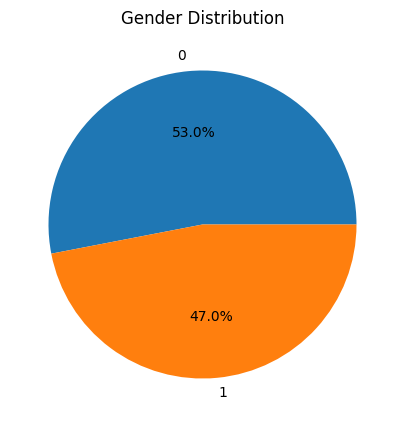

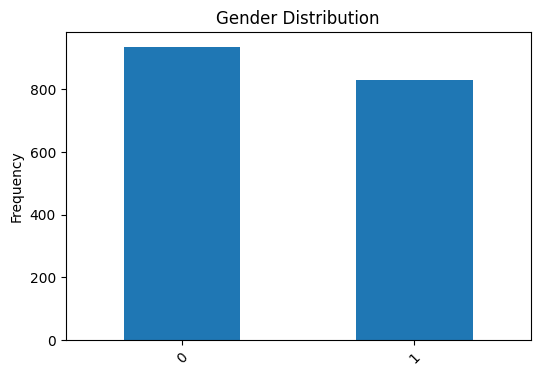

In [14]:
plot_pie(gender_table, "Gender Distribution")
plot_bar(gender_table, "Gender Distribution")

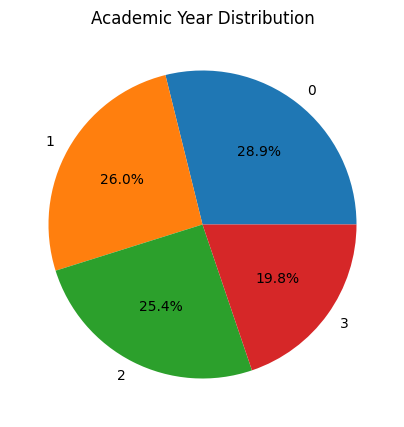

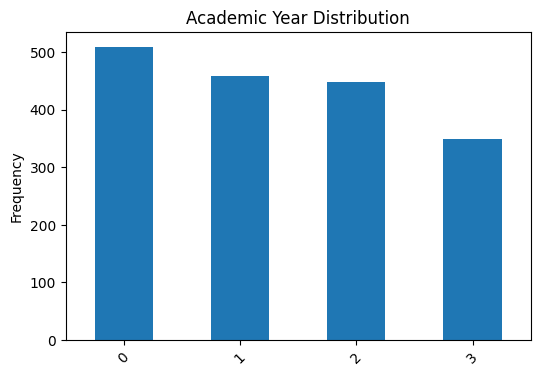

In [15]:
plot_pie(year_table, "Academic Year Distribution")
plot_bar(year_table, "Academic Year Distribution")

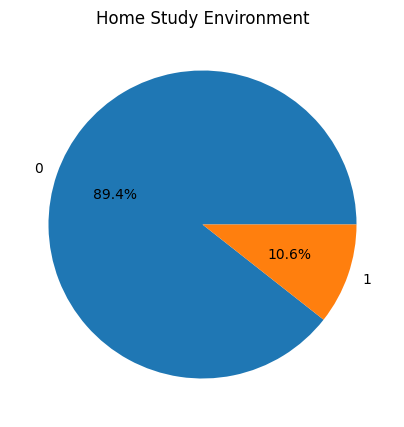

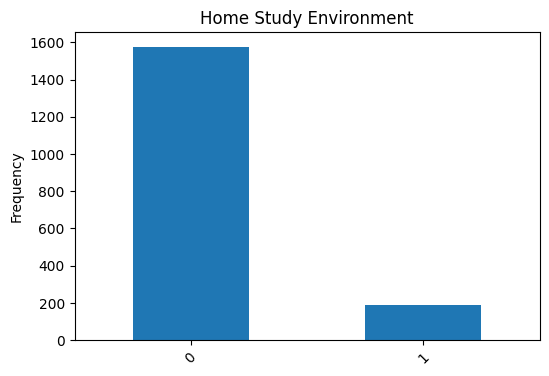

In [16]:
plot_pie(home_env_table, "Home Study Environment")
plot_bar(home_env_table, "Home Study Environment")

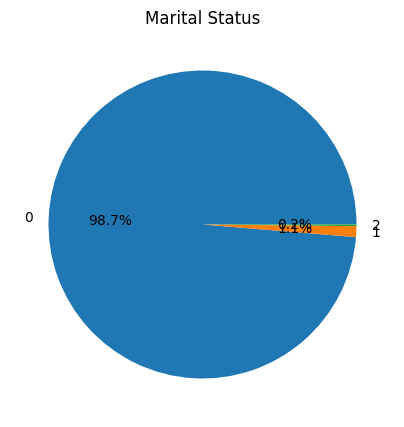

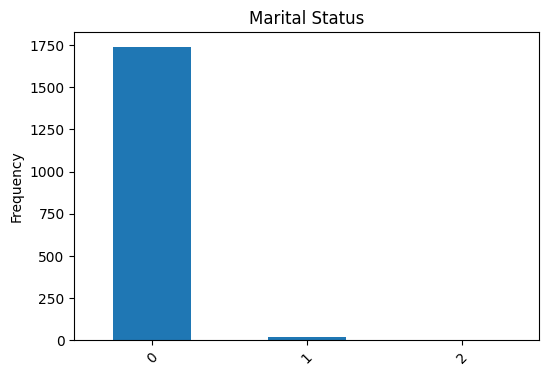

In [17]:
plot_pie(marital_table, "Marital Status")
plot_bar(marital_table, "Marital Status")

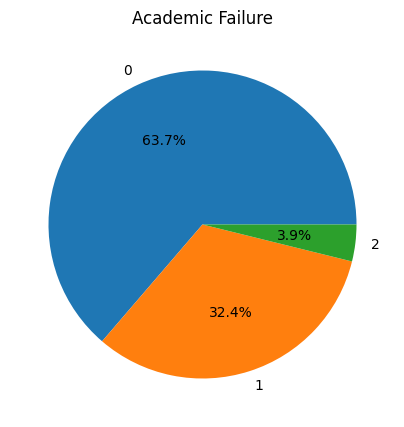

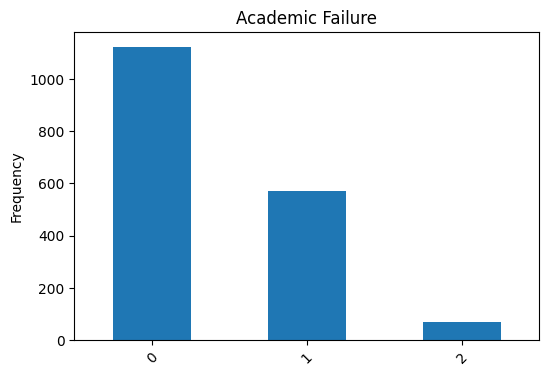

In [18]:
plot_pie(failure_table, "Academic Failure")
plot_bar(failure_table, "Academic Failure")

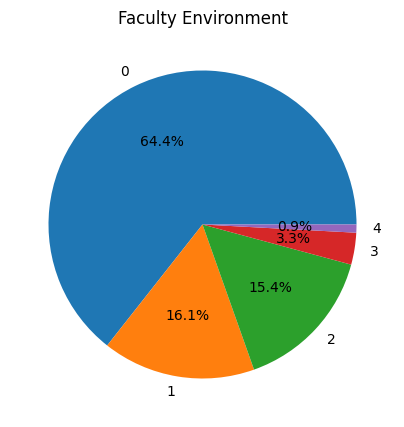

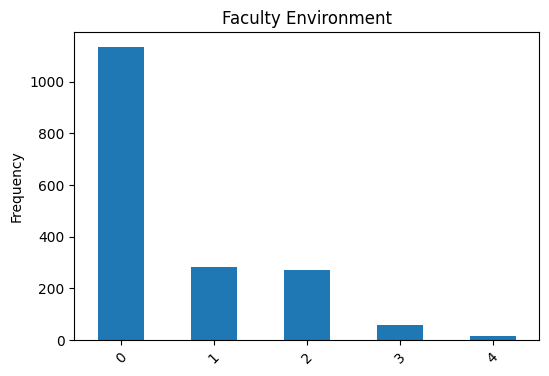

In [19]:
plot_pie(faculty_env_table, "Faculty Environment")
plot_bar(faculty_env_table, "Faculty Environment")